In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy import stats as spstats
import librosa
from IPython.display import Audio, display

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 3)
plt.rcParams['axes.grid'] = True

RNG = np.random.default_rng(42)
FS = 2000  # Hz — cuantas muestras por segundo va a tener nuestro audio de prueba

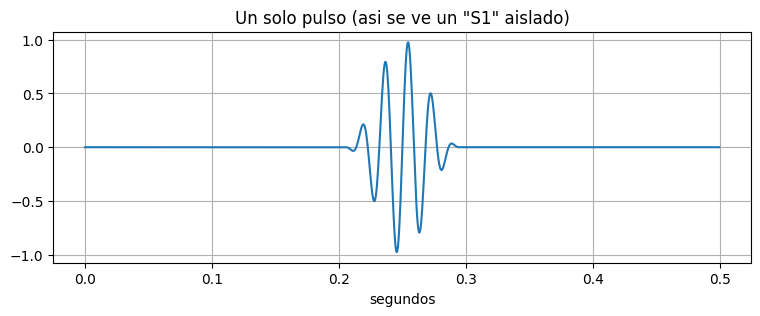

In [2]:
def hann_pulse(t, center, dur, freq, amp):
    out = np.zeros_like(t)                                  # empezamos en puro silencio
    mask = (t >= center - dur/2) & (t <= center + dur/2)     # que parte del tiempo cae dentro del pulso
    n = mask.sum()
    if n == 0:
        return out
    window = np.hanning(n)                                  # la envolvente: sube y baja suave
    carrier = np.sin(2*np.pi*freq*(t[mask]-center))          # el tono puro (seno)
    out[mask] = amp * window * carrier                       # tono x envolvente = pulso limpio
    return out

# probemoslo con un pulso aislado, para verlo solo
t = np.arange(0, 0.5, 1/FS)   # medio segundo, casi todo va a ser silencio
pulso = hann_pulse(t, center=0.25, dur=0.09, freq=55, amp=1.0)

plt.plot(t, pulso)
plt.title('Un solo pulso (asi se ve un "S1" aislado)')
plt.xlabel('segundos')
plt.show()